In [31]:
from sklearn.datasets import load_diabetes 
import seaborn as sns
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [32]:
df = load_diabetes(as_frame=True).frame

In [33]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [34]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()
X = df.drop("target", axis=1)
y=df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = DecisionTreeRegressor()
model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [35]:
from sklearn.metrics import r2_score, mean_squared_error

In [36]:
y_pre_train = model.predict(X_train)
y_pre_test = model.predict(X_test)

In [37]:
print("MSE: y_pre_train ",mean_squared_error(y_train, y_pre_train) )
print("MSE: y_pre_test ",mean_squared_error(y_test, y_pre_test) )
print("r2_score: y_pre_train ",r2_score(y_train, y_pre_train) )
print("r2_score: y_pre_train ",r2_score(y_test, y_pre_test) )


MSE: y_pre_train  0.0
MSE: y_pre_test  5573.06015037594
r2_score: y_pre_train  1.0
r2_score: y_pre_train  -0.03237169798354955


[Text(0.578392507219472, 0.9722222222222222, 'bmi <= 0.005\nsquared_error = 6148.282\nsamples = 309\nvalue = 153.903'),
 Text(0.3224718956270627, 0.9166666666666666, 's5 <= 0.014\nsquared_error = 3636.316\nsamples = 183\nvalue = 118.355'),
 Text(0.45043220142326734, 0.9444444444444444, 'True  '),
 Text(0.19780063943894388, 0.8611111111111112, 's2 <= 0.091\nsquared_error = 2641.993\nsamples = 138\nvalue = 102.855'),
 Text(0.15225350660066006, 0.8055555555555556, 's5 <= -0.043\nsquared_error = 2392.062\nsamples = 136\nvalue = 100.816'),
 Text(0.07106023102310231, 0.75, 's1 <= -0.039\nsquared_error = 1519.474\nsamples = 42\nvalue = 78.952'),
 Text(0.04806105610561056, 0.6944444444444444, 's1 <= -0.046\nsquared_error = 1850.165\nsamples = 24\nvalue = 94.792'),
 Text(0.03341584158415842, 0.6388888888888888, 'age <= -0.0\nsquared_error = 1134.5\nsamples = 20\nvalue = 82.0'),
 Text(0.02392739273927393, 0.5833333333333334, 's3 <= 0.036\nsquared_error = 756.596\nsamples = 15\nvalue = 74.733'),


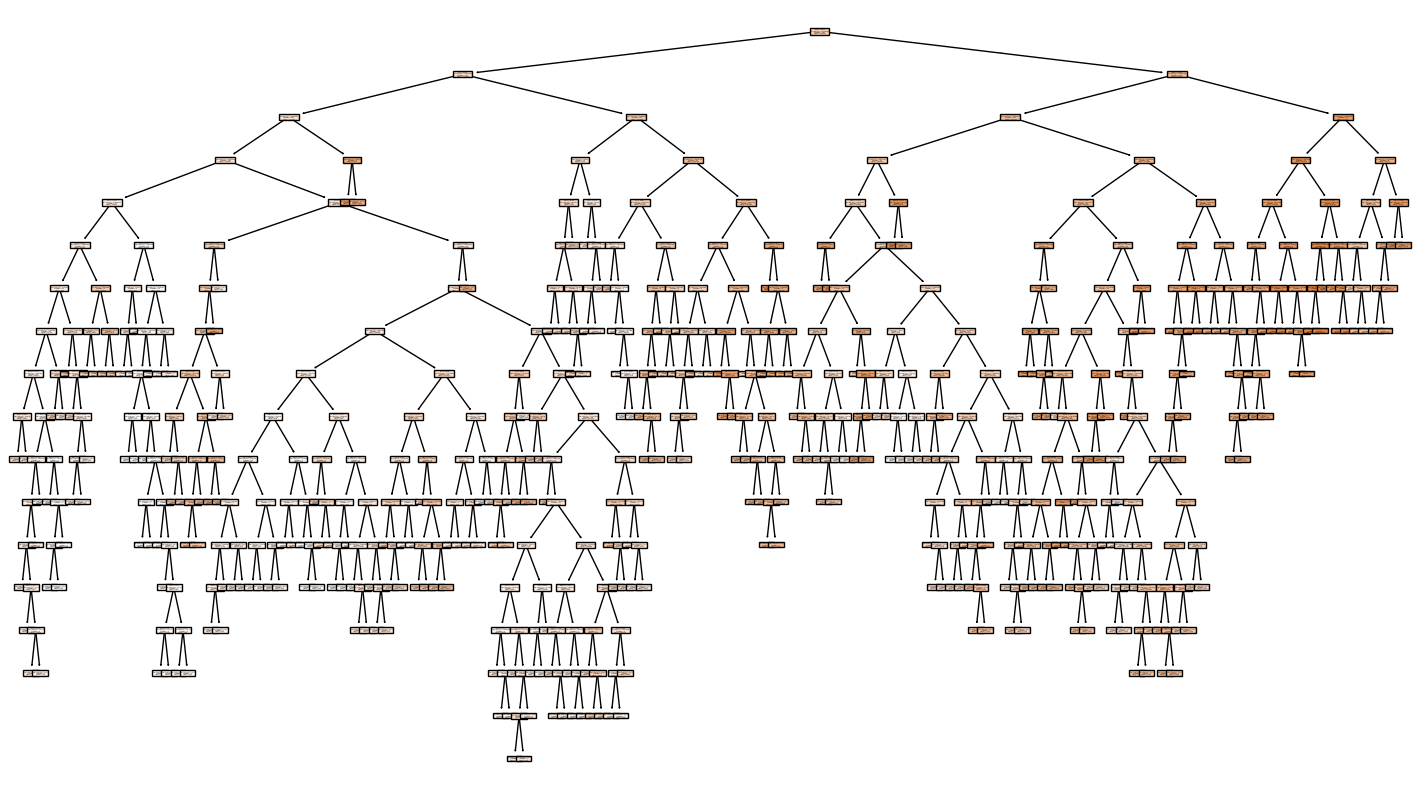

In [44]:
from sklearn.tree  import plot_tree
plt.figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died", "survived"],
    filled=True,
    
)

In [46]:

print("Train R²:", model.score(X_train, y_train))
print("Test R² :", model.score(X_test, y_test))

Train R²: 1.0
Test R² : -0.03237169798354955


In [49]:
path = model.cost_complexity_pruning_path(
    X_train,
    y_train
)

ccp_alphas = path.ccp_alphas

In [51]:
from sklearn.model_selection import cross_val_score

cv_scores = []

for alpha in ccp_alphas:

    tree = DecisionTreeRegressor(
        ccp_alpha=alpha,
        random_state=42
    )

    scores = cross_val_score(
        tree,
        X_train,
        y_train,
        cv=5,
        scoring="r2"
    )

    cv_scores.append(scores.mean())

In [52]:
best_index = cv_scores.index(max(cv_scores))

best_alpha = ccp_alphas[best_index]

print("Best Alpha:", best_alpha)
print("Best CV Score:", cv_scores[best_index])

Best Alpha: 98.46201958761253
Best CV Score: 0.30721718311621177


In [55]:
final_model = DecisionTreeRegressor(ccp_alpha=best_alpha)
final_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,np.float64(98.46201958761253)


In [57]:
print("MSE: y_pre_train ",mean_squared_error(y_train, y_pre_train) )
print("MSE: y_pre_test ",mean_squared_error(y_test, y_pre_test) )
print("r2_score: y_pre_train ",r2_score(y_train, y_pre_train) )
print("r2_score: y_pre_test ",r2_score(y_test, y_pre_test) )


MSE: y_pre_train  0.0
MSE: y_pre_test  5573.06015037594
r2_score: y_pre_train  1.0
r2_score: y_pre_test  -0.03237169798354955
